# **ID Tim Capstone Project	: A25-CS309**
### ID Use Case			: [AC-06] Customer Segmentation for Personalized Retail Marketing
### List Anggota :    
#### 1. M891D5X0064 - Afifah Zahra Ramadhani
#### 2. M128D5X1410 - Muhtria Harlika
#### 3. M891D5X1784 - Sabrina Yusrina

# **Import Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import seaborn as sns
import subprocess
import joblib

from google.colab import files
from datetime import datetime
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, davies_bouldin_score

# **Data Loading**

In [ ]:
# Download latest version
path = kagglehub.dataset_download("carrie1/ecommerce-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-data' dataset.
Path to dataset files: /kaggle/input/ecommerce-data


In [ ]:
print("Isi folder:", os.listdir(path))

Isi folder: ['data.csv']


In [ ]:
mainPath = os.path.join(path, "data.csv")
data = pd.read_csv(mainPath, encoding='latin1')

# **Exploratory Data Analysis (EDA)**

In [ ]:
df = data.copy()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Identifikasi Missing Value
Pada tahap eksplorasi awal, akan dilakukan pengecekan untuk mengetahui apakah terdapat data yang tidak lengkap atau kosong pada atribut penting. Data yang hilang ini berpotensi mengganggu proses analisis karena dapat mengurangi keakuratan informasi pelanggan. Oleh karena itu, jika ditemukan missing value, data tersebut perlu ditangani atau dihapus agar analisis selanjutnya lebih valid.

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


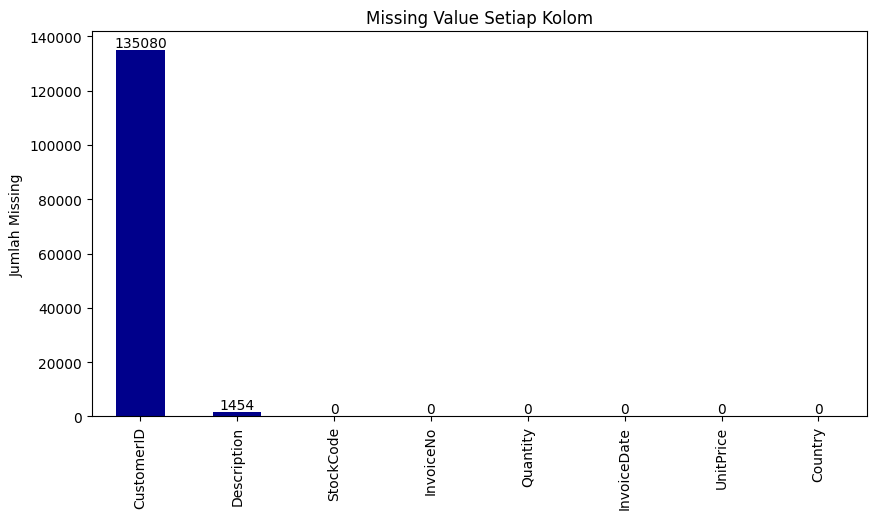

In [ ]:
plt.figure(figsize=(10,5))

missing = df.isnull().sum().sort_values(ascending=False)
ax = missing.plot(kind='bar', color='darkblue')

plt.title("Missing Value Setiap Kolom")
plt.ylabel("Jumlah Missing")

# Menambahkan label angka pada setiap bar
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.show()

Visualisasi di atas menunjukkan jumlah missing value pada setiap kolom dalam dataset dapat dilihat bahwa:
- Kolom **CustomerID** memiliki missing value yang paling tinggi, yaitu sekitar 135.080 baris yang tidak memiliki ID pelanggan.
- Kolom **Description** juga memiliki missing value sejumlah 1.454 baris.
- Kolom lainnya seperti StockCode, InvoiceNo, Quantity, InvoiceDate, UnitPrice, dan Country tidak mengandung missing value sehingga tidak memerlukan penanganan khusus terkait data hilang.

Berdasarkan jumlah missing pada CustomerID menggambarkan bahwa banyak transaksi yang tidak mencantumkan identitas pelanggan, kemungkinan karena pembelian dilakukan tanpa registrasi. Untuk analisis clustering berbasis RFM, keberadaan CustomerID sangat penting karena perhitungan RFM memerlukan identitas unik pelanggan. Oleh karena itu, akan dilakukan cleaning pada tahap preprocessing
dengan menghapus baris yang memiliki missing value pada kolom CustomerID dan Description menggunakan `dropna()`.

## Identifikasi Baris Duplikat
Dataset juga mengandung sejumlah baris duplikat, yang menunjukkan adanya pencatatan transaksi yang sama lebih dari satu kali. Keberadaan duplikat dapat menyebabkan perhitungan frekuensi dan nilai transaksi menjadi tidak akurat. Untuk memastikan integritas data, seluruh baris duplikat akan dihapus pada tahap preprocessing.

In [ ]:
# Menemukan baris duplikat dan mengurutkan data berdasarkan kolom
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows_sorted = duplicate_rows.sort_values(by=['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])

# Menampilkan 10 baris pertama
duplicate_rows_sorted.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


Hasil pengecekan menunjukkan bahwa dataset mengandung baris duplikat yang berpotensi menyebabkan bias dalam analisis, terutama pada perhitungan jumlah transaksi dan nilai pembelian. Oleh karena itu, baris duplikat akan dihapus pada tahap preprocessing menggunakan `df.drop_duplicates()` untuk memastikan dataset lebih akurat dan tidak terjadi penggandaan informasi yang memengaruhi proses analisis RFM selanjutnya.

## Identifikasi Anomali StockCode
Dalam analisis RFM (Recency, Frequency, Monetary), tujuan utama adalah memahami perilaku pembelian customer berdasarkan transaksi produk yang benar-benar dibeli. Oleh karena itu, beberapa StockCode yang tidak merepresentasikan produk perlu dihapus agar tidak mengganggu akurasi perhitungan RFM.

In [ ]:
#Cari StockCode yang mengandung huruf
df[df['StockCode'].str.contains('[A-Za-z]', regex=True, na=False)]['StockCode'].unique()

array(['85123A', '84406B', '84029G', ..., '85179a', '90214U', '47591b'],
      dtype=object)

In [ ]:
#Cek StockCode yang tidak hanya angka
df[~df['StockCode'].str.isnumeric()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
45,536370,POST,POSTAGE,3,12/1/2010 8:45,18.00,12583.0,France
...,...,...,...,...,...,...,...,...
541778,581578,84997C,CHILDRENS CUTLERY POLKADOT BLUE,8,12/9/2011 12:16,4.15,12713.0,Germany
541809,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,12/9/2011 12:19,1.79,17581.0,United Kingdom
541838,581580,84993A,75 GREEN PETIT FOUR CASES,2,12/9/2011 12:20,0.42,12748.0,United Kingdom
541844,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,12/9/2011 12:20,1.25,12748.0,United Kingdom


In [ ]:
#Menghitung jumlah StockCode unik
unique_stock_codes = df['StockCode'].nunique()
unique_stock_codes

4070

In [ ]:
#Mengambil daftar kode StockCode unik
unique_stock_codes = df['StockCode'].unique()

#Menghitung jumlah karakter angka dalam setiap StockCode
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()
numeric_char_counts_in_unique_codes

,count
5,4037
4,14
0,13
6,5
1,1


In [ ]:
#Mendeteksi Anomali
anomali = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

print("Anomali StockCode:")
for code in anomali:
    print(code)

Anomali StockCode:
POST
D
C2
DOT
M
BANK CHARGES
S
AMAZONFEE
m
DCGSSBOY
DCGSSGIRL
PADS
B
CRUK


In [ ]:
# Mengecek beberapa deskripsinya
df[df['StockCode'].isin(['POST','M','C2','BANK CHARGES', 'PADS','DOT'])][['StockCode','Description', 'Quantity', 'UnitPrice']].head(20)

,StockCode,Description,Quantity,UnitPrice
45,POST,POSTAGE,3,18.00
386,POST,POSTAGE,1,15.00
1123,POST,POSTAGE,1,18.00
1423,C2,CARRIAGE,1,50.00
1814,DOT,DOTCOM POSTAGE,1,569.77
2239,M,Manual,1,1.25
2250,M,Manual,1,18.95
3041,DOT,DOTCOM POSTAGE,1,607.49
4406,BANK CHARGES,Bank Charges,1,15.00
5073,POST,POSTAGE,1,18.00


Dari hasil pengecekan, ditemukan sejumlah **StockCode** yang tidak merepresentasikan produk penjualan. Kode-kode ini umumnya merupakan:
- Biaya tambahan (misalnya ongkir, biaya administrasi bank, biaya platform)
- Penyesuaian sistem atau manual adjustment
- Kode internal yang tidak terkait produk
- Item non-produk seperti packaging, charity fee, atau layanan tambahan

Beberapa contoh kode anomali meliputi:
POST, D, C2, DOT, M, BANK CHARGES, S, AMAZONFEE, m, DCGSSBOY, DCGSSGIRL, PADS, B, CRUK, dan sejumlah kode serupa lainnya.

Kode-kode tersebut berpotensi:
- Meningkatkan atau menurunkan Monetary secara tidak wajar
- Menambah Frequency padahal bukan transaksi pembelian
- Mengubah Recency jika transaksi terakhir bukan pembelian
- Menyebabkan klaster RFM menjadi tidak representatif

Untuk menjaga integritas analisis RFM, seluruh StockCode yang teridentifikasi sebagai non-produk harus dihapus, sehingga hanya transaksi pembelian valid yang digunakan dalam perhitungan Recency, Frequency, dan Monetary.

## Identifikasi Item Non‐Produk pada Kolom Description

Dalam dataset retail, Description biasanya ditulis dengan huruf kapital. Jika ada item yang mengandung huruf kecil (lowercase), biasanya itu tanda tidak konsisten formatnya. Oleh karena itu, langkah ini dipakai untuk menemukan inkonsistensi data.

Top 10 Produk Terlaris (Berdasarkan Kuantitas):
                             Description  Quantity
4009   WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
1866             JUMBO BAG RED RETROSPOT     47363
244        ASSORTED COLOUR BIRD ORNAMENT     36381
2740                      POPCORN HOLDER     36334
2395     PACK OF 72 RETROSPOT CAKE CASES     36039
3918  WHITE HANGING HEART T-LIGHT HOLDER     35317
2803                  RABBIT NIGHT LIGHT     30680
2161             MINI PAINT SET VINTAGE      26437
2361          PACK OF 12 LONDON TISSUES      26315
2393  PACK OF 60 PINK PAISLEY CAKE CASES     24753


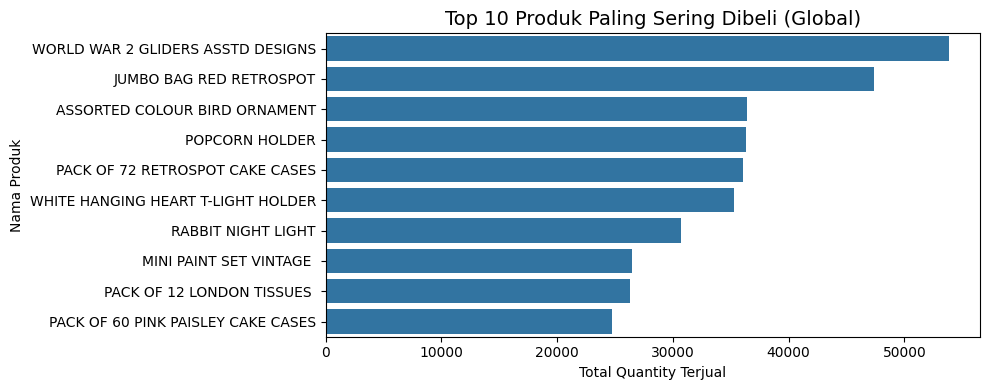

In [ ]:
# Hitung total quantity per produk
top_products = df.groupby('Description')['Quantity'].sum().reset_index()

# Ambil 10 produk dengan jumlah penjualan terbanyak
top_10_products = top_products.sort_values(by='Quantity', ascending=False).head(10)

print("Top 10 Produk Terlaris (Berdasarkan Kuantitas):")
print(top_10_products[['Description', 'Quantity']])

# Visualisasi
plt.figure(figsize=(10, 4))
sns.barplot(data=top_10_products, y='Description', x='Quantity')
plt.title('Top 10 Produk Paling Sering Dibeli (Global)', fontsize=14)
plt.xlabel('Total Quantity Terjual')
plt.ylabel('Nama Produk')
plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi Top 10 Produk Terlaris, terlihat bahwa semua nilai pada kolom **Description** ditulis dalam huruf kapital, menunjukkan bahwa penamaan produk kemungkinan mengikuti format standar input data. Untuk memastikan konsistensi penulisan, dilakukan pengecekan tambahan terhadap deskripsi yang menggunakan huruf kecil atau campuran huruf, karena pola tersebut sering kali mengindikasikan item non-produk, entri error, atau pencatatan tidak sesuai format.

In [ ]:
lowercase_desc = df['Description'].unique()

# Mendeteksi deskripsi yang memiliki huruf kecil
lowercase_desc = [desc for desc in lowercase_desc if isinstance(desc, str) and any(char.islower() for char in desc)]

print("Deskripsi unik yang berisi karakter huruf kecil :")
for desc in lowercase_desc:
    print(desc)

Deskripsi unik yang berisi karakter huruf kecil :
Discount
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
BAG 125g SWIRLY MARBLES
BAG 250g SWIRLY MARBLES
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
Manual
Dr. Jam's Arouzer Stress Ball
3 TRADITIONAl BISCUIT CUTTERS  SET
Bank Charges
NUMBER TILE COTTAGE GARDEN No
amazon
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
check
damages
Dad's Cab Electronic Meter
NUMBER TILE VINTAGE FONT No 
*Boombox Ipod Classic
faulty
Dotcom sales
amazon sales
*USB Office Mirror Ball
POLYESTER FILLER PAD 30CMx30CM
Dotcomgiftshop Gift Voucher £40.00
Found
Dotcomgiftshop Gift Voucher £50.00
reverse 21/5/10 adjustment
Dotcomgiftshop Gift Voucher £30.00
Dotcomgiftshop Gift Voucher £20.00
mouldy, thrown away.
found
counted
Given away
Dotcom
label mix up
samples/damages
thrown away
incorrectly made-thrown away.
showroom
Adjustment
Dotcomgiftshop Gift Voucher £10.00

Diketahui bahwa kolom Description tidak hanya berisi nama produk fisik, tetapi juga mencakup sejumlah item non-produk. Contohnya adalah deskripsi seperti “Next Day Carriage” dan “High Resolution Image”, yang masing-masing merepresentasikan biaya pengiriman dan layanan tambahan, bukan barang yang dibeli pelanggan. Keberadaan item non-produk seperti ini dapat mengganggu proses analisis, khususnya dalam perhitungan **Monetary** pada metode RFM, karena nilai transaksi yang tidak mencerminkan pembelian produk sebenarnya dapat menyebabkan hasil analisis menjadi bias. Oleh karena itu, item-item tersebut perlu diidentifikasi dan dihapus pada tahap preprocessing agar dataset yang digunakan hanya berfokus pada transaksi produk fisik dan menghasilkan analisis yang lebih akurat dan representatif.

## Identifikasi Outliers
Kemudian melakukan identifikasi nilai-nilai ekstrem yang berbeda jauh dari mayoritas data. Outlier dapat mempengaruhi distribusi data dan hasil analisis, terutama pada perhitungan nilai transaksi dan segmentasi pelanggan. Jika nilai ekstrem ditemukan, akan dilakukan penanganan untuk memastikan data lebih stabil dan representatif.

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Berdasarkan hasil `df.describe()`, ditemukan beberapa karakteristik penting pada variabel numerik, khususnya **Quantity** dan **UnitPrice**, yang menunjukkan adanya kebutuhan untuk melakukan proses pembersihan data lebih lanjut.

1. Nilai 0 dan Negatif pada Quantity dan UnitPrice

Dari tabel deskriptif terlihat bahwa:
- Quantity memiliki nilai minimum sebesar −80995,
- UnitPrice memiliki nilai minimum sebesar −11062.

Kehadiran nilai negatif ini mengindikasikan adanya transaksi seperti refund, cancellation, atau adjustment yang tidak relevan untuk analisis perilaku pelanggan, terutama pada tahapan perhitungan RFM.
Selain itu, baik Quantity maupun UnitPrice juga dapat memiliki nilai 0, yang mencerminkan transaksi tidak valid atau item non-produk. Nilai 0 dan negatif ini berpotensi mengganggu perhitungan Monetary serta interpretasi frekuensi pembelian.

2. Outlier Ekstrem pada Quantity dan UnitPrice

Selain nilai negatif, hasil EDA juga menunjukkan keberadaan outlier ekstrem:
- Quantity maksimum mencapai 80995,
- UnitPrice maksimum mencapai 38970,

Nilai maksimum ini sangat jauh dari nilai kuartil 75% (Q3), yaitu:

Q3 Quantity = 10 dan Q3 UnitPrice = 4.13

Perbedaan yang sangat besar ini menandakan adanya transaksi dengan jumlah yang tidak wajar, kemungkinan akibat kesalahan input (human error), Item non-produk atau biaya tertentu yang tidak mencerminkan perilaku pembelian biasa. Outlier ekstrem ini berpotensi membuat distribusi Monetary menjadi sangat bias, yang pada akhirnya dapat mempengaruhi hasil clustering pada tahap RFM.

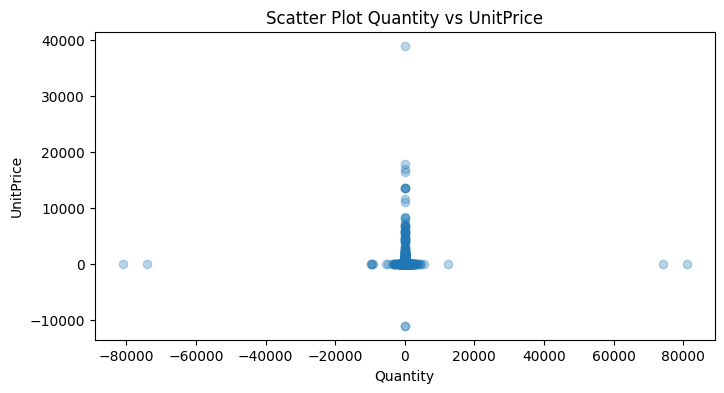

In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(df['Quantity'], df['UnitPrice'], alpha=0.3)
plt.title("Scatter Plot Quantity vs UnitPrice")
plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.show()

Scatter plot menunjukkan adanya banyak nilai ekstrem (outlier) pada variabel **Quantity** dan **UnitPrice**. Terlihat bahwa sebagian besar titik data terpusat di sekitar nilai kecil, namun terdapat beberapa titik yang menyimpang jauh, seperti Quantity mencapai lebih dari 80.000 dan UnitPrice mencapai lebih dari 39.000, serta beberapa nilai negatif pada kedua variabel. Oleh karena itu, pada tahap preprocessing akan dilakukan pembersihan data untuk menghapus nilai negatif dan menangani outlier ekstrem menggunakan teknik `IQR` (Interquartile Range) agar hasil analisis selanjutnya lebih akurat.

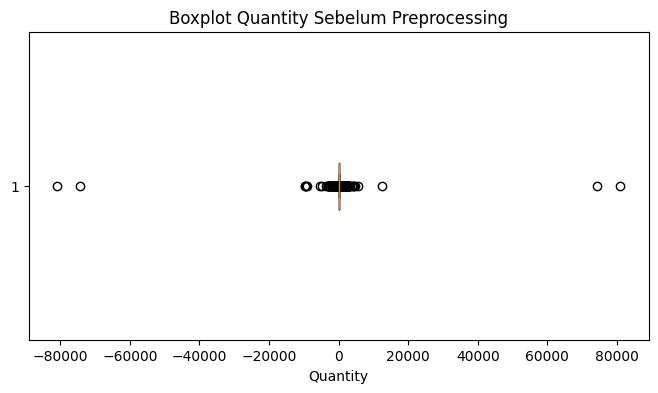

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(df['Quantity'], vert=False)
plt.title("Boxplot Quantity Sebelum Preprocessing")
plt.xlabel("Quantity")
plt.show()

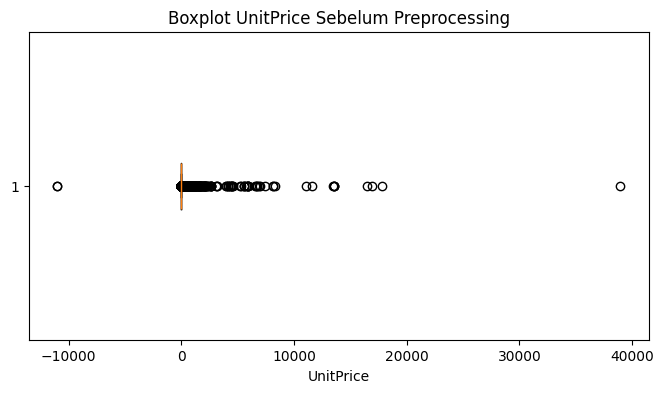

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(df['UnitPrice'], vert=False)
plt.title("Boxplot UnitPrice Sebelum Preprocessing")
plt.xlabel("UnitPrice")
plt.show()

# **Data Preprocessing**

## Menghapus missing value dari kolom CustomerID dan Description

In [ ]:
df = df.dropna(subset=['CustomerID', 'Description'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


## Menghapus baris yang memiliki duplikat

In [ ]:
print(f"Terdapat {df.duplicated().sum()} baris duplikat yang perlu dihapus")

Terdapat 5225 baris duplikat yang perlu dihapus


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(401604, 8)

## Menghapus StockCode yang Tidak Wajar

In [ ]:
df = df[~df['StockCode'].isin(anomali)]

In [ ]:
df['StockCode'].isin(anomali).sum()

np.int64(0)

In [ ]:
df.shape

(399689, 8)

## Menghapus Item Non-Produk pada Kolom Description

In [ ]:
anomali_desc = ["Next Day Carriage", "High Resolution Image"]
anomali_desc = [x.lower().strip() for x in anomali_desc]

df = df[~df['Description'].str.lower().str.strip().isin(anomali_desc)]

In [ ]:
#Standarisasi konsistensi format Description
df['Description'] = df['Description'].str.upper()

In [ ]:
df.shape

(399606, 8)

## Menghapus baris dari kolom Quantity dan UnitPrice yang memiliki nilai 0 dan negatif

In [ ]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [ ]:
(df[['Quantity', 'UnitPrice']] <= 0).sum()

,0
Quantity,0
UnitPrice,0


In [ ]:
df.shape

(391068, 8)

## Menghapus Outliers ekstrem

Masalah:
- Quantity ada yang hingga 80.995 unit.

- Harga ada yang mencapai 649.

- Angka ekstrem ini mengganggu clustering (KMeans sangat sensitif terhadap outlier).

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,391068.000000,391068.000000,391068.000000
mean,13.147844,2.871841,15295.134849
std,180.826701,4.281445,1710.345760
min,1.000000,0.040000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15158.000000
75%,12.000000,3.750000,16794.000000
max,80995.000000,649.500000,18287.000000


In [ ]:
# IQR untuk Quantity
Q1_qty = df['Quantity'].quantile(0.25)
Q3_qty = df['Quantity'].quantile(0.75)

IQR_qty = Q3_qty - Q1_qty

lower_qty = Q1_qty - 1.5 * IQR_qty
upper_qty = Q3_qty + 1.5 * IQR_qty

In [ ]:
print("Quantity :")
print(f"Q1 Quantity  : {Q1_qty}")
print(f"Q3 Quantity  : {Q3_qty}")
print(f"IQR Quantity : {IQR_qty}")
print(f"Lower Qty    : {lower_qty}")
print(f"Upper Qty    : {upper_qty}")

Quantity :
Q1 Quantity  : 2.0
Q3 Quantity  : 12.0
IQR Quantity : 10.0
Lower Qty    : -13.0
Upper Qty    : 27.0


In [ ]:
# IQR untuk UnitPrice
Q1_price = df['UnitPrice'].quantile(0.25)
Q3_price = df['UnitPrice'].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

In [ ]:
print("UnitPrice :")
print(f"Q1 UnitPrice    : {Q1_price}")
print(f"Q3 UnitPrice    : {Q3_price}")
print(f"IQR UnitPrice   : {IQR_price}")
print(f"Lower UnitPrice : {lower_price}")
print(f"Upper UnitPrice : {upper_price}")

UnitPrice :
Q1 UnitPrice    : 1.25
Q3 UnitPrice    : 3.75
IQR UnitPrice   : 2.5
Lower UnitPrice : -2.5
Upper UnitPrice : 7.5


In [ ]:
# Filter data berdasarkan batas IQR
df_clean = df[
    (df['Quantity'] >= lower_qty) & (df['Quantity'] <= upper_qty) &
    (df['UnitPrice'] >= lower_price) & (df['UnitPrice'] <= upper_price)
]

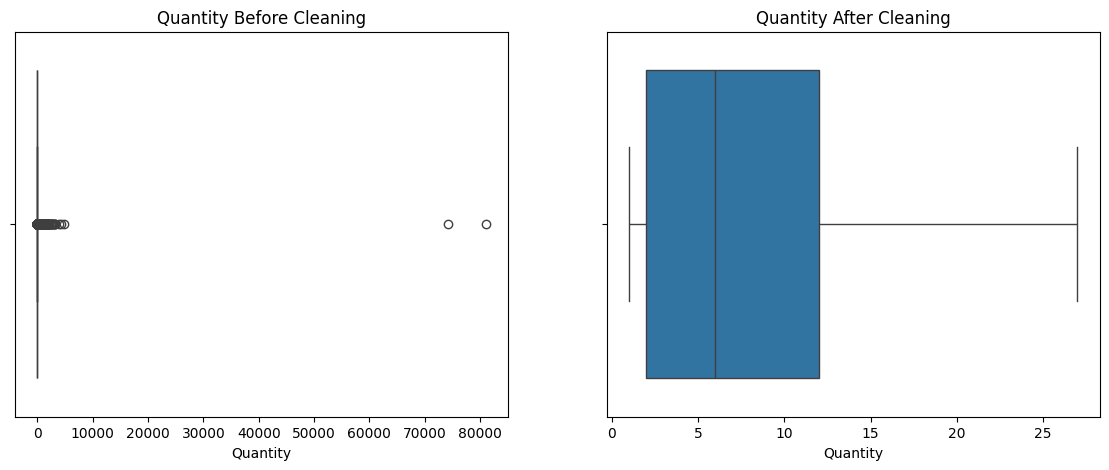

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Quantity'])
plt.title("Quantity Before Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=df_clean['Quantity'])
plt.title("Quantity After Cleaning")

plt.show()

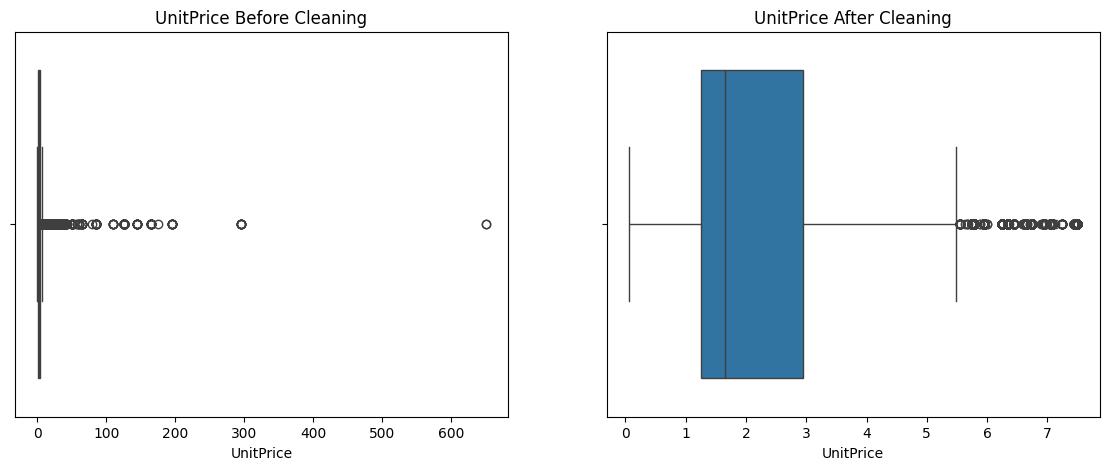

In [ ]:
# Visualisasi Before vs After
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['UnitPrice'])
plt.title("UnitPrice Before Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=df_clean['UnitPrice'])
plt.title("UnitPrice After Cleaning")

plt.show()

In [ ]:
df_clean.shape

(333043, 8)

In [ ]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# **Feature Engineering**

### Skenario 1 - Standard RFM (Baseline)

In [ ]:
# 1. Persiapan Data
# Convert 'InvoiceDate' to datetime objects
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2. Skenario 1: Standard RFM (Baseline)
# Ini adalah pendekatan klasik customer segmentation
rfm_base = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
}).reset_index()

rfm_base.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print("Skenario 1 (RFM Only) terbentuk.")
rfm_base.head()

/tmp/ipython-input-4068210630.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
/tmp/ipython-input-4068210630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']


Skenario 1 (RFM Only) terbentuk.


,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,7,3314.73
1,12348.0,249,3,90.20
2,12349.0,19,1,999.15
3,12350.0,310,1,294.40
4,12352.0,36,7,1130.94


Meskipun RFM adalah standar industri, menggunakan hanya 3 fitur ini memiliki keterbatasan dalam konteks Retail/E-commerce ini:

1.  **Tidak Membedakan Reseller vs End-User:** Dua customer bisa memiliki `Monetary` dan `Frequency` yang sama, tapi customer A membeli 100 unit barang yang sama (kemungkinan reseller), sedangkan customer B membeli 100 barang berbeda (rumah tangga). RFM tidak menangkap ini.
2.  **Keteraturan Pola Belanja:** RFM melihat *jumlah* transaksi (`Frequency`), tapi tidak melihat *konsistensi* jeda antar transaksi.
3.  **Lokasi:** Perilaku market lokal (UK) seringkali berbeda dengan market ekspor.

Oleh karena itu, kita akan melakukan **enrichment** (penambahan fitur) untuk menghasilkan segmentasi yang lebih tajam.

### Skenario 2 : Behavior

In [ ]:
# Skenario 2: Menambahkan Behavioral Features (Advanced)

customer_data = rfm_base.copy()

# a. Product Variety (Berapa jenis barang unik yang dibeli?)
# Menjawab kelemahan 1: Membedakan tipe pembeli
variety_feat = df_clean.groupby('CustomerID')['StockCode'].nunique().reset_index()
variety_feat.rename(columns={'StockCode': 'Product_Variety'}, inplace=True)

# b. Avg Days Between Purchases (Seberapa rutin mereka kembali?)
# Menjawab kelemahan 2: Melihat konsistensi
df_clean['InvoiceDay'] = df_clean['InvoiceDate'].dt.date
days_between = df_clean.groupby('CustomerID')['InvoiceDay'].apply(
    lambda x: (x.diff().dropna()).apply(lambda y: y.days).mean()
)
days_between = days_between.reset_index(name='Avg_Days_Between_Purchases')

# c. Geographic Feature (UK vs Non-UK)
# Menjawab kelemahan 3: Konteks lokasi
customer_country = df_clean.groupby(['CustomerID', 'Country']).size().reset_index().sort_values(0, ascending=False).drop_duplicates('CustomerID')
is_uk_feat = customer_country[['CustomerID', 'Country']].copy()
is_uk_feat['Is_UK'] = is_uk_feat['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

# Gabungan semua fitur
customer_data = customer_data.merge(variety_feat, on='CustomerID', how='left')
customer_data = customer_data.merge(days_between, on='CustomerID', how='left')
# Isi NaN di Days Between dengan 0 (artinya baru beli 1x, belum ada jeda)
customer_data['Avg_Days_Between_Purchases'] = customer_data['Avg_Days_Between_Purchases'].fillna(0)
# Merge Is_UK
customer_data = customer_data.merge(is_uk_feat[['CustomerID', 'Is_UK']], on='CustomerID', how='left')

print(f"Skenario 2 (Enriched) terbentuk. Dimensi: {customer_data.shape}")
customer_data.head()

/tmp/ipython-input-126495544.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['InvoiceDay'] = df_clean['InvoiceDate'].dt.date


Skenario 2 (Enriched) terbentuk. Dimensi: (4191, 7)


,CustomerID,Recency,Frequency,Monetary,Product_Variety,Avg_Days_Between_Purchases,Is_UK
0,12347.0,2,7,3314.73,96,2.212121,0
1,12348.0,249,3,90.20,6,22.000000,0
2,12349.0,19,1,999.15,58,0.000000,0
3,12350.0,310,1,294.40,16,0.000000,0
4,12352.0,36,7,1130.94,49,4.000000,0


### Transformasi Data

menggunakan Log Transformation untuk menangani outlier VIP, lalu baru di-Scale
supaya tidak menghapus VIP customer (outlier atas), tapi memadatkan distribusi datanya.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Handling Outlier & Scaling

# Fitur yang akan dipakai untuk Clustering (Is_UK kita exclude dulu dari clustering agar murni perilaku)
cols_features = ['Recency', 'Frequency', 'Monetary', 'Product_Variety', 'Avg_Days_Between_Purchases']

# Log Transformation
customer_data_log = customer_data.copy()
for col in cols_features:
    customer_data_log[col] = np.log1p(customer_data_log[col])

# Scaling (StandardScaler)
scaler = StandardScaler()
customer_data_scaled = scaler.fit_transform(customer_data_log[cols_features])

# Hasil akhir siap untuk Modeling
customer_data_scaled = pd.DataFrame(customer_data_scaled, columns=cols_features)

print("Data siap untuk Modeling (Log Transformed + Scaled).")
describe_scaled = customer_data_scaled.describe().round(2)
describe_scaled

Data siap untuk Modeling (Log Transformed + Scaled).


,Recency,Frequency,Monetary,Product_Variety,Avg_Days_Between_Purchases
count,4191.00,4191.00,4191.00,4191.00,4191.00
mean,-0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.35,-0.95,-4.09,-2.46,-0.96
25%,-0.67,-0.95,-0.67,-0.66,-0.96
50%,0.09,-0.33,-0.02,0.04,-0.12
75%,0.86,0.44,0.69,0.73,0.63
max,1.57,6.00,4.15,3.51,4.98


Mean = 0 & Std = 1: Terlihat mean semuanya 0.00 dan std semuanya 1.00. Ini tandanya StandardScaler bekerja sempurna. Sekarang semua fitur punya "bobot" yang setara di mata algoritma K-Means.

### Korelasi

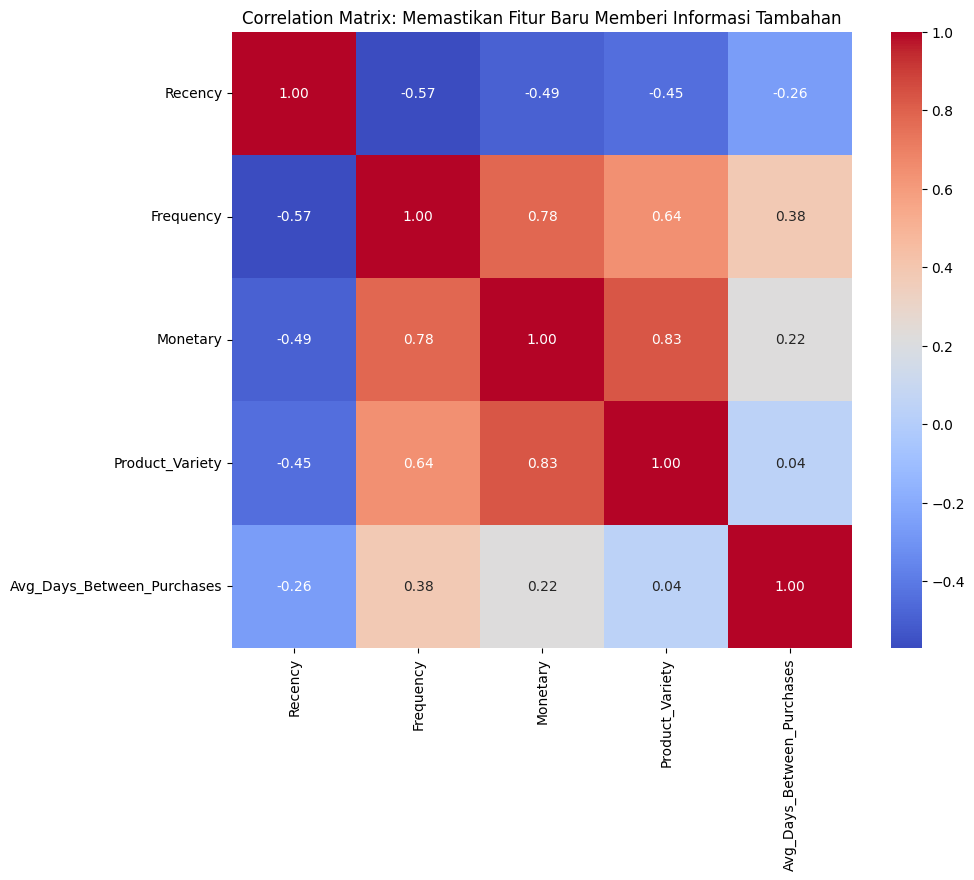

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Hitung korelasi pada data yang sudah di-scale
corr_matrix = customer_data_scaled.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Memastikan Fitur Baru Memberi Informasi Tambahan")
plt.show()

Berdasarkan Correlation Matrix, seluruh fitur yang dipilih (RFM + Variety + Behavior) layak digunakan untuk pemodelan:

Tidak ada redundansi: Nilai korelasi tertinggi adalah 0.83 (Monetary vs Variety), masih di bawah ambang batas multikolinearitas (0.90).

Nilai Tambah Fitur Baru:

Avg_Days_Between_Purchases memiliki korelasi sangat rendah terhadap RFM, menandakan fitur ini memberikan dimensi baru (pola keteraturan) yang unik.

Product_Variety memiliki korelasi 0.64 dengan Frequency, membuktikan bahwa fitur ini mampu membedakan karakteristik pembelian (misal: Reseller yang beli massal vs End-user yang beli variatif) yang tidak tertangkap oleh Frequency saja.

# **Data Modelling**

Mulai mencari jumlah cluster optimal dengan Elbow Method...


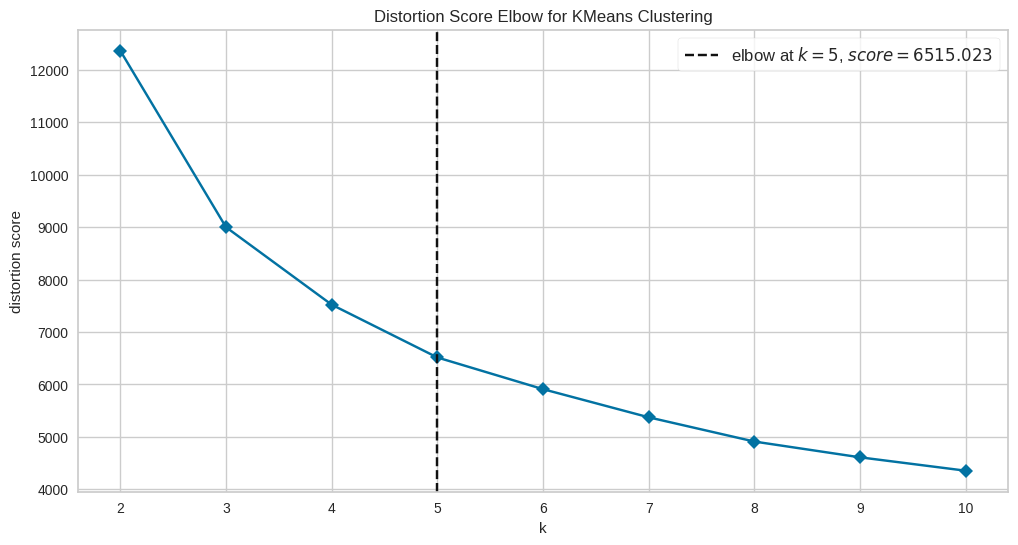

Grafik Elbow Method selesai ditampilkan.


In [ ]:
print("Mulai mencari jumlah cluster optimal dengan Elbow Method...")

# Setup Model KMeans
model = KMeans(init='k-means++', n_init=10, random_state=42)

# Visualisasi Elbow Method
plt.figure(figsize=(12, 6))

visualizer = KElbowVisualizer(model, k=(2,11), timings=False)

visualizer.fit(customer_data_scaled)        # Fit data yang sudah di-scale
visualizer.show()                           # Tampilkan grafik

print("Grafik Elbow Method selesai ditampilkan.")

### K-Means

In [ ]:
# K-Means dengan k=5 (Sesuai hasil Elbow Method)
kmeans_final = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
kmeans_final.fit(customer_data_scaled)

# Masukkan Label Cluster ke Data Customer
customer_data['Cluster'] = kmeans_final.labels_

print("Clustering Selesai. Data customer kini memiliki label Cluster (0-4).")
customer_data.head()

Clustering Selesai. Data customer kini memiliki label Cluster (0-4).


,CustomerID,Recency,Frequency,Monetary,Product_Variety,Avg_Days_Between_Purchases,Is_UK,Cluster
0,12347.0,2,7,3314.73,96,2.212121,0,3
1,12348.0,249,3,90.20,6,22.000000,0,4
2,12349.0,19,1,999.15,58,0.000000,0,0
3,12350.0,310,1,294.40,16,0.000000,0,0
4,12352.0,36,7,1130.94,49,4.000000,0,2


In [ ]:
print("--- Evaluasi Kualitas Clustering ---")

# 1. Hitung Silhouette Score
# (Semakin dekat ke 1 semakin bagus)
sil_score = silhouette_score(customer_data_scaled, kmeans_final.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

# 2. Hitung Davies-Bouldin Index
# (Semakin kecil / mendekati 0 semakin bagus)
db_score = davies_bouldin_score(customer_data_scaled, kmeans_final.labels_)
print(f"Davies-Bouldin Index: {db_score:.4f}")

# --- Interpretasi ---
if sil_score > 0.5:
    print("\nKesimpulan: Struktur Cluster SANGAT KUAT.")
elif sil_score > 0.25:
    print("\nKesimpulan: Struktur Cluster CUKUP BAIK (Wajar untuk data perilaku manusia).")
else:
    print("\nKesimpulan: Struktur Cluster LEMAH (Data mungkin terlalu overlapping).")

--- Evaluasi Kualitas Clustering ---
Silhouette Score: 0.2676
Davies-Bouldin Index: 1.1907

Kesimpulan: Struktur Cluster CUKUP BAIK (Wajar untuk data perilaku manusia).


### Profiling Cluster

Profil Rata-Rata Tiap Cluster (Angka Asli)
   Cluster  Recency  Frequency  Monetary  Product_Variety  \
1        1   182.09       1.04    103.35             6.37   
0        0   141.18       1.22    351.97            30.89   
4        4    76.70       2.95    381.29            17.51   
2        2    49.55       4.00  1,109.71            71.58   
3        3    12.40      13.67  3,842.79           162.97   

   Avg_Days_Between_Purchases  Total_Customers  Percentage  
1                        0.03              663       15.82  
0                        0.20             1048       25.01  
4                       15.41              657       15.68  
2                        2.64             1242       29.63  
3                        1.77              581       13.86  


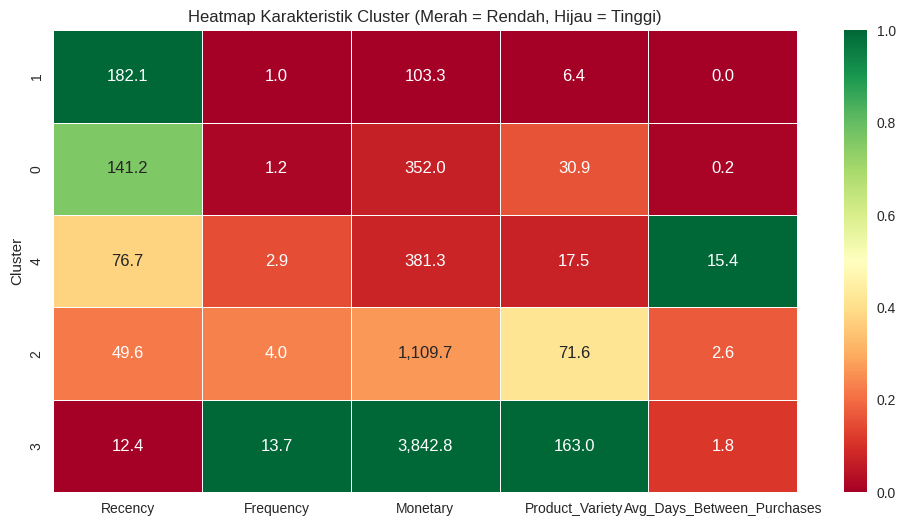

In [ ]:
# Hitung rata-rata tiap fitur berdasarkan Cluster
cluster_summary = customer_data.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Product_Variety': 'mean',
    'Avg_Days_Between_Purchases': 'mean',
    'CustomerID': 'count' # Hitung jumlah orang
}).reset_index()

# Rename kolom count
cluster_summary.rename(columns={'CustomerID': 'Total_Customers'}, inplace=True)

# Tambahkan Persentase Populasi
cluster_summary['Percentage'] = (cluster_summary['Total_Customers'] / cluster_summary['Total_Customers'].sum()) * 100

# Urutkan berdasarkan Monetary
cluster_summary = cluster_summary.sort_values(by='Monetary', ascending=True)

print("Profil Rata-Rata Tiap Cluster (Angka Asli)")
# Tampilkan angka dengan format rapi
pd.options.display.float_format = '{:,.2f}'.format
print(cluster_summary)

# Visualisasi Gradient
plt.figure(figsize=(12, 6))

summary_norm = cluster_summary.drop(columns=['Total_Customers', 'Percentage']).set_index('Cluster')
summary_norm = (summary_norm - summary_norm.min()) / (summary_norm.max() - summary_norm.min())

sns.heatmap(summary_norm, annot=cluster_summary.drop(columns=['Total_Customers', 'Percentage']).set_index('Cluster'),
            cmap='RdYlGn', fmt=',.1f', linewidths=0.5)
plt.title('Heatmap Karakteristik Cluster (Merah = Rendah, Hijau = Tinggi)')
plt.show()

# **Insight**

Distribusi Segmen Final:
Segment
Loyal Customers         1242
Hibernating             1048
Lost / Low Value         663
Occasional / At Risk     657
Champions (VIP)          581
Name: count, dtype: int64


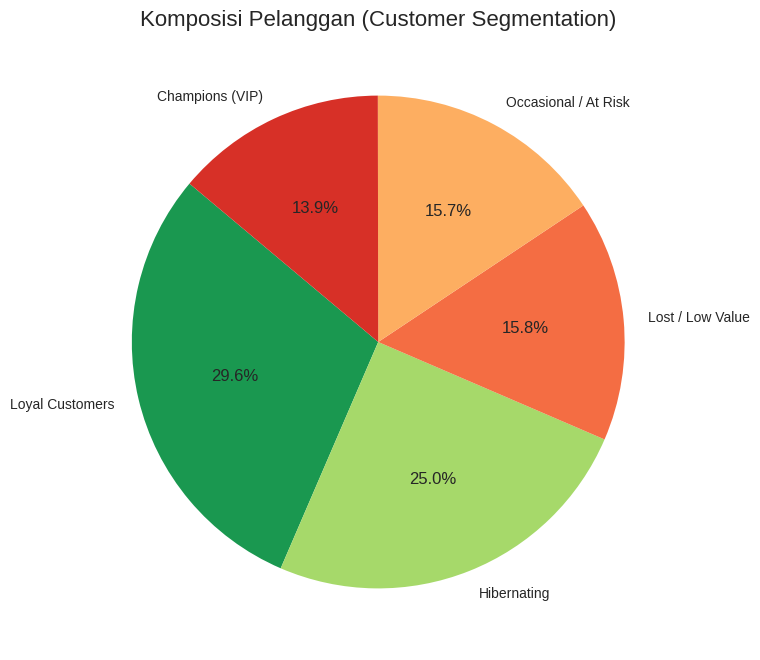

In [ ]:
# Labelling

# Mapping berdasarkan analisis karakteristik (Cluster 3 = Paling Sultan, Cluster 1 = Paling Rendah)
segment_map = {
    3: 'Champions (VIP)',           # Recency: 12 hari, Frequency: 13,67 kali, Monetary: Rp 3.842, Product Variety: 162 jenis, Avg Days Between Purchases: 1,77 hari.
    2: 'Loyal Customers',           # Recency: 49 hari, Frequency: 4 kali, Monetary: Rp 1.109, Product Variety: 71 jenis, Avg Days Between Purchases: 2,64 hari.
    4: 'Occasional / At Risk',      # Recency: 76 hari, Frequency: 2,95, Monetary: Rp 381, Product Variety: 17,5, Avg Days Between Purchases: 151 hari.
    0: 'Hibernating',               # Recency: 141 hari, Frequency: 1,22, Monetary: Rp 351, Product Variety: 30,89, Avg Days Between Purchases: 0,20 hari.
    1: 'Lost / Low Value'           # Recency: 182 hari, Frequency: 1,04, Monetary: Rp 103, Product Variety: 6,37, Avg Days Between Purchases: 0,03 hari.
}

# Terapkan Mapping ke DataFrame
customer_data['Segment'] = customer_data['Cluster'].map(segment_map)

# Cek Distribusi Akhir
print("Distribusi Segmen Final:")
print(customer_data['Segment'].value_counts())

# Visualisasi Pie Chart untuk Laporan
plt.figure(figsize=(8, 8))
counts = customer_data['Segment'].value_counts()
colors = ['#1a9850', '#a6d96a', '#f46d43', '#fdae61', '#d73027'] # Hijau ke Merah

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Komposisi Pelanggan (Customer Segmentation)', fontsize=16)
plt.show()

### Interpretasi Hasil Clustering & Strategi Bisnis

Berdasarkan hasil pemodelan K-Means dengan **k=5**, berikut adalah profil mendalam dari setiap segmen pelanggan beserta rekomendasi strategi bisnis yang disarankan.

---

## 1. Champions (VIP) - Cluster 3
**"Pelanggan Sultan / High Value"**

* **Populasi:** 13.86% (Sedikit tapi sangat berharga)
* **Karakteristik Utama:**
    * **Recency:** Sangat baru (~12 hari).
    * **Frequency:** Sangat sering (~13x transaksi).
    * **Monetary:** Kontribusi pendapatan tertinggi (**$3,842**).
    * **Insight:** Membeli variasi produk sangat tinggi (162 jenis), indikasi *heavy user* atau *reseller*.

> **Rekomendasi Strategi:**
> * **VIP Treatment:** Berikan layanan prioritas (CS khusus/jalur cepat).
> * **Early Access:** Berikan akses pembelian produk baru sebelum rilis umum.
> * **No Discounts Needed:** Jangan 'bakar uang' dengan diskon harga, ganti dengan *reward* eksklusif atau hadiah fisik untuk menjaga prestise.

---

## 2. Loyal Customers - Cluster 2
**"Tulang Punggung Pendapatan"**

* **Populasi:** 29.63% (Segmen Terbesar)
* **Karakteristik Utama:**
    * **Recency:** Cukup baru (~49 hari).
    * **Frequency:** Stabil (~4x transaksi).
    * **Insight:** Performa solid dan konsisten. Ini adalah basis pelanggan yang menjaga arus kas perusahaan tetap stabil.

> **Rekomendasi Strategi:**
> * **Up-selling:** Tawarkan produk varian yang lebih premium/mahal.
> * **Cross-selling:** Rekomendasikan produk pelengkap berdasarkan riwayat belanja mereka (misal: Beli sepatu, tawarkan kaos kaki).
> * **Gamification:** Dorong mereka masuk ke level *Champions* dengan program *Loyalty Points*.

---

## 3. Occasional / At Risk - Cluster 4
**"Pelanggan Rutin tapi Jarang"**

* **Populasi:** 15.68%
* **Karakteristik Utama:**
    * **Avg Days Between:** Memiliki jeda belanja rutin terlama (~15 hari).
    * **Monetary:** Rendah ($381).
    * **Insight:** Mereka punya pola belanja, tapi siklusnya lambat. Ada risiko mereka lupa kembali jika tidak diingatkan.

> **Rekomendasi Strategi:**
> * **Smart Reminder:** Kirim notifikasi/email pengingat saat mendekati prediksi waktu belanja mereka.
> * **Urgency:** Berikan *Limited Time Offer* (Promo Terbatas Waktu) untuk memicu urgensi agar siklus belanja menjadi lebih cepat.

---

## 4. Hibernating - Cluster 0
**"Pelanggan Tidur"**

* **Populasi:** 25.01%
* **Karakteristik Utama:**
    * **Recency:** Lama tidak belanja (~141 hari).
    * **Frequency:** Rendah (~1.2x).
    * **Insight:** Dulu pernah aktif (bukan *Lost*), tapi sekarang pasif. Potensi untuk dibangunkan kembali masih ada.

> **Rekomendasi Strategi:**
> * **Win-Back Campaign:** Lakukan pendekatan agresif dengan diskon "We Miss You".
> * **Feedback Loop:** Kirim survei kepuasan pelanggan untuk mengetahui alasan mereka berhenti (apakah harga, layanan, atau pesaing?).

---

## 5. Lost / Low Value - Cluster 1
**"Sudah Churn"**

* **Populasi:** 15.82%
* **Karakteristik Utama:**
    * **Recency:** Sangat lama (~182 hari).
    * **Monetary:** Sangat kecil ($103).
    * **Insight:** Performa terburuk di semua metrik RFM. Kemungkinan besar sudah pindah ke kompetitor.

> **Rekomendasi Strategi:**
> * **Efficiency Strategy:** Jangan habiskan budget marketing yang mahal di sini (ROI rendah).
> * **Automation:** Cukup sertakan dalam *broadcast* email umum/otomatisasi, fokuskan sumber daya tim marketing ke segmen Champions dan Loyal.

## Hasil

In [ ]:
installed_packages = ["numpy", "pandas", "matplotlib", "seaborn", "kagglehub", "scikit-learn", "joblib", "seaborn", "yellowbrick"]


with open("requirements.txt", "w") as f:
    for pkg in installed_packages:
        # Capture output of `pip show {pkg}` using subprocess
        try:
            result = subprocess.run(['pip', 'show', pkg], capture_output=True, text=True, check=True)
            pip_show_output = result.stdout.splitlines()
        except subprocess.CalledProcessError:
            pip_show_output = [] # Handle case where package info is not found

        # Filter for the line containing "Version:" and extract the version
        version = "Not Found"
        for line in pip_show_output:
            if "Version:" in line:
                version = line.split(":")[1].strip()
                break

        f.write(f"{pkg}=={version}\n")

In [ ]:
# Pilih kolom yang diinginkan saja dari data utama (customer_data)
raw_segment_rfm = customer_data[['Segment', 'Recency', 'Frequency', 'Monetary']]
raw_segment_rfm.to_csv('cluster_profile.csv', index=False)

print(raw_segment_rfm.head())

                Segment  Recency  Frequency  Monetary
0       Champions (VIP)        2          7  3,314.73
1  Occasional / At Risk      249          3     90.20
2           Hibernating       19          1    999.15
3           Hibernating      310          1    294.40
4       Loyal Customers       36          7  1,130.94


In [ ]:
# menyimpan Model K-Means
joblib.dump(kmeans_final, 'kmeans_customer_segmentation_model.joblib')

# menyimpan scaler
joblib.dump(scaler, 'scaler_model.joblib')

print("Model dan Scaler berhasil disimpan!")

# download
files.download('kmeans_customer_segmentation_model.joblib')
files.download('scaler_model.joblib')

Model dan Scaler berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

customer_country_real = df_clean.groupby(['CustomerID', 'Country']).size().reset_index(name='count')
customer_country_real = customer_country_real.sort_values('count', ascending=False).drop_duplicates('CustomerID')

if 'Country' in customer_data.columns:
    customer_data = customer_data.drop(columns=['Country'])

customer_data = customer_data.merge(customer_country_real[['CustomerID', 'Country']], on='CustomerID', how='left')

output_cols = [
    'CustomerID',
    'Segment',
    'Recency',
    'Frequency',
    'Monetary',
    'Product_Variety',
    'Avg_Days_Between_Purchases',
    'Is_UK',
    'Country'
]

customer_data[output_cols].to_csv('Capstone_Result_Segmented.csv', index=False)
print(customer_data[output_cols].head())

   CustomerID               Segment  Recency  Frequency  Monetary  \
0   12,347.00       Champions (VIP)        2          7  3,314.73   
1   12,348.00  Occasional / At Risk      249          3     90.20   
2   12,349.00           Hibernating       19          1    999.15   
3   12,350.00           Hibernating      310          1    294.40   
4   12,352.00       Loyal Customers       36          7  1,130.94   

   Product_Variety  Avg_Days_Between_Purchases  Is_UK  Country  
0               96                        2.21      0  Iceland  
1                6                       22.00      0  Finland  
2               58                        0.00      0    Italy  
3               16                        0.00      0   Norway  
4               49                        4.00      0   Norway  
